In [6]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neural_network import MLPRegressor
from sklearn.base import BaseEstimator
from typing import Callable
from sklearn.metrics import mean_absolute_error, accuracy_score, mean_absolute_percentage_error, r2_score, root_mean_squared_error
import pandas as pd
import bambi as bmb
import arviz as az

# custom 
from utils import ts_parents, all_formulas_from_structures, train_regime_models_bayesian, classify_regime_bayesian, sliding_window_regime_prediction

In [ ]:
# data with estimate regime from rpcmci and true regime for test data
data = pd.read_csv("data/simulated_time_series.csv")

In [5]:
#-- causal structures estimated with RPCMCI for each regime
causal_structures = {
    # Regime 0
    0: {
        "X0": [(0, -1)],
        "X1": [(1, -1)],
        "X2": [(3, -1), (2, -1)],
        "X3": [(3, -1)],
        "X4": [(4, -1)]
    },
    # Regime 1
    1: {
        "X0": [(0, -1)],
        "X1": [(1, -1)],
        "X2": [(0, -1), (1, -1), (2, -1)],
        "X3": [(4, -1), (3, -1)],
        "X4": [(4, -1)]
    }
}

In [6]:
#-- prepare training data
train = data[:500]
#-- filter training data by estimated regime
train1 = train[train['regime'] == 1].drop(columns=['regime'])
train0 = train[train['regime'] == 0].drop(columns=['regime'])
train1_features = ts_parents(train1, causal_structures[1])
train0_features = ts_parents(train0, causal_structures[0])
X_train = {0:train0_features,1:train1_features} # dataset for each regime

In [8]:
all_formulas = all_formulas_from_structures(causal_structures)

In [11]:
bayesian_models = train_regime_models_bayesian(X=X_train, 
                                               all_formulas=all_formulas)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [X0_sigma, Intercept, X0_lag1]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 43 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [X1_sigma, Intercept, X1_lag1]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [X2_sigma, Intercept, X3_lag1, X2_lag1]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 39 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [X3_sigma, Intercept, X3_lag1]
Sampling 4 chains for 1_000 tune and 1_000 draw iterati

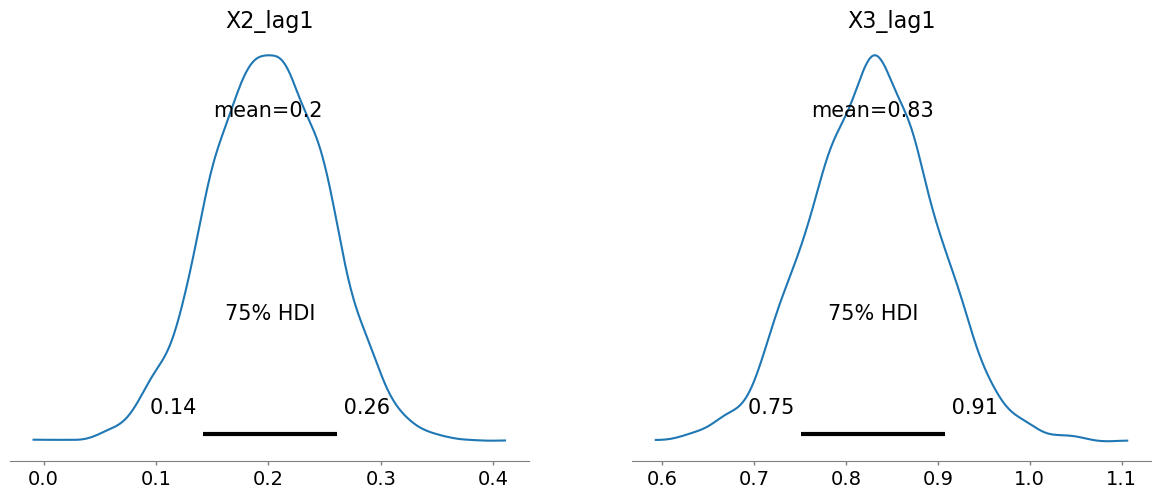

In [12]:
# Regime 0 posterior X2 
#-- regime_models: regime, variable, [model, idata]
az.plot_posterior(bayesian_models[0]["X2"]["idata"], var_names=['X2_lag1','X3_lag1'], hdi_prob=.75);

In [113]:
test = data[492:]
actual_regimes = test[['regime']]
test_data = test.drop(columns=['regime'])

test0 = ts_parents(df=test_data, 
                   causal_structure=causal_structures[0]) 
test1 = ts_parents(df=test_data, 
                   causal_structure=causal_structures[1]) 

X_test = {0:test0,1:test1} # test dataset for each regime

In [54]:
regime_prediction, errors = classify_regime_bayesian(
    X_test=X_test, 
    all_formulas=all_formulas, 
    bayesian_models=bayesian_models,
    causal_structures=causal_structures
)

In [56]:
# classify regime 
true_regime = actual_regimes[6:].values.reshape(-1,)
accuracy_score(regime_prediction[5:], true_regime)

0.7761194029850746

In [57]:
# classify regime with a sliding window of the last w errors 
w = 7
window_preds = sliding_window_regime_prediction(errors, window_size=w)
true_regime = actual_regimes[w:].values.reshape(-1,)
accuracy_score(window_preds, true_regime)

0.99

# Forecasting

In [88]:
data

,X0,X1,X2,X3,X4,regime
0,0.257400,-0.908481,-0.378503,-0.534916,0.858073,1.0
1,-0.310050,0.225644,1.259195,1.703038,-0.095986,1.0
2,-0.470458,0.523013,-1.304859,-0.418364,0.454517,1.0
3,-0.312497,2.092040,-0.868509,-0.854187,-0.707811,1.0
4,-0.110958,0.466782,3.633895,-1.150839,-0.228680,1.0
...,...,...,...,...,...,...
695,-0.883166,-0.254717,-2.028361,-1.130587,-0.419178,1.0
696,-0.690289,-1.194611,-1.864770,-0.846455,0.078497,1.0
697,0.064097,-0.483377,-1.592902,-1.121033,2.240269,1.0
698,0.883625,-0.730529,-1.354966,2.313916,1.784288,1.0


In [248]:
# add the classified regimes to dataset (instead of the true labels) for test data
test_data =  data[498:].copy()
test_data['regime'][2:] = window_preds

In [249]:
# shift regime one step (the previous classified regime it the causal structure for the forecast)
test_data['regime'] = test_data['regime'].shift(1)
test_data.dropna(inplace=True)

In [ ]:
# do not shift the classified regime from previous step
test_data =  data[499:].copy()
test_data['regime'][1:] = window_preds

In [250]:
# same causal structure in both (shared across each time series)
test = ts_parents(test_data, causal_structures[0])


test1_features= test[test['regime'] == 1].drop(columns=['regime'])
test0_features = test[test['regime'] == 0].drop(columns=['regime'])

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# Forecasting with CaReBayes

## forecasting regime 0

In [293]:
# forecasting with bayesian autoregressive model 

# #-- bayesian_models: [regime], [variable], [model, idata]
#-- e.g., bayesian_models[0]["X2"]["idata"]
model = bayesian_models[0]["X2"]["model"]
idata = bayesian_models[0]["X2"]["idata"]


preds0 = model.predict(idata=idata, data=test0_features, kind="pps", inplace=False)
preds0 = preds0.posterior_predictive["X2"]  

mean_pred = preds0.mean(dim=("chain", "draw")).values
lower = preds0.quantile(0.025, dim=("chain", "draw")).values
upper = preds0.quantile(0.975, dim=("chain", "draw")).values

y_test = test0_features["X2"]
y_pred = mean_pred

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.5014207288315722
MAE: 0.7701394234249085
RMSE: 1.0084877356794335
MAPE: 2.7548317690507975


In [294]:
y_preds_total = []
upper_total = []
lower_total = []
y_preds_total.append(y_pred)
upper_total.append(upper) 
lower_total.append(lower)

## forecasting regime 1

In [ ]:
# forecasting with bayesian autoregressive model 

# #-- bayesian_models: [regime], [variable], [model, idata]
#-- e.g., bayesian_models[0]["X2"]["idata"]
model = bayesian_models[1]["X2"]["model"]
idata = bayesian_models[1]["X2"]["idata"]


preds1 = model.predict(idata=idata, data=test1_features, kind="pps", inplace=False)
preds1 = preds1.posterior_predictive["X2"]  

mean_pred = preds1.mean(dim=("chain", "draw")).values
lower = preds1.quantile(0.025, dim=("chain", "draw")).values
upper = preds1.quantile(0.975, dim=("chain", "draw")).values

y_test = test1_features["X2"]
y_pred = mean_pred

# Evaluate the model
r2 = r2_metric(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.6605623796652249
MAE: 0.8561833019126283
RMSE: 1.0432329811702492
MAPE: 2.6769924093566995


In [298]:
y_preds_total.append(y_pred)
upper_total.append(upper) 
lower_total.append(lower)

In [299]:
bayesian_predictions = np.concatenate((y_preds_total[0], y_preds_total[1]))
bayesian_lower = np.concatenate((lower_total[0], lower_total[1]))
bayesian_upper = np.concatenate((upper_total[0], upper_total[1]))

In [301]:
x2_actual = test["X2"].values

## forecasting over complete test set (regime 0 and 1)

In [302]:
y_pred = bayesian_predictions.copy()
y_test = x2_actual

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.594589508700804
MAE: 0.8101498269216981
RMSE: 1.0247908172447215
MAPE: 2.718636466793042


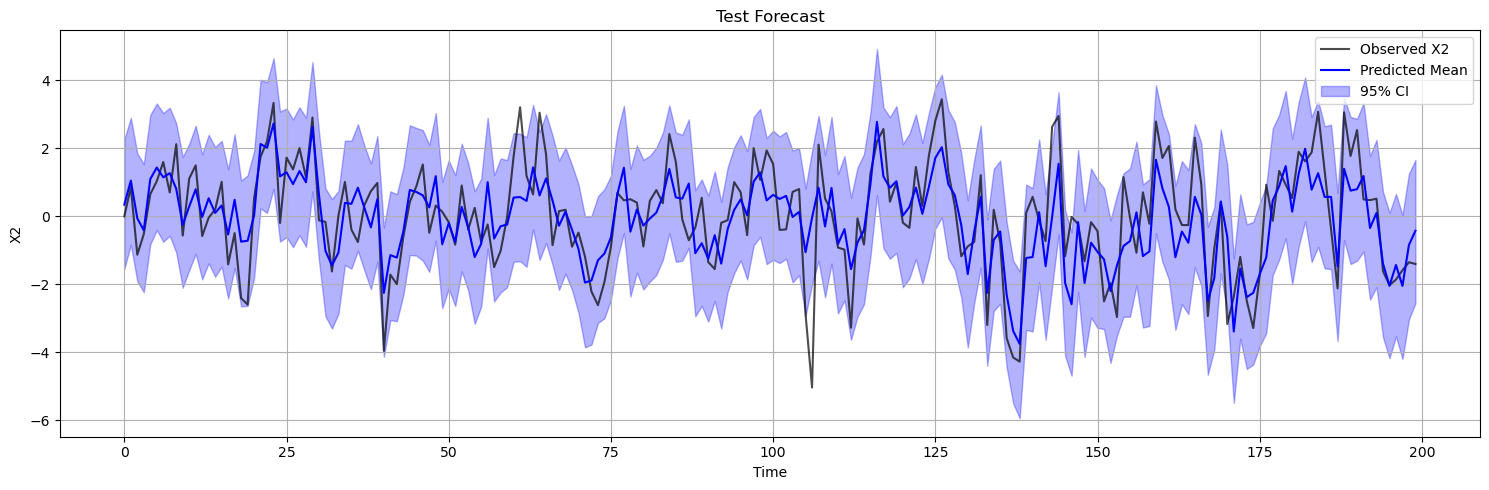

In [303]:
plt.figure(figsize=(15, 5))

# Plot the observed values of X2
plt.plot(range(len(x2_actual)), x2_actual, label="Observed X2", color="black", alpha=0.7)

# Plot the predicted posterior mean
plt.plot(range(len(x2_actual)), bayesian_predictions, label="Predicted Mean", color="blue")

# Plot the uncertainty band (95% credible interval)
plt.fill_between(range(len(x2_actual)), bayesian_lower, bayesian_upper, color="blue", alpha=0.3, label="95% CI")

# Labels and legend
plt.legend()
plt.xlabel("Time")
plt.ylabel("X2")
plt.title("Test Forecast")
plt.grid(True)
plt.tight_layout()
plt.show()

# Benchmark Forecasting Models

## Markov-Switching VAR benchmark

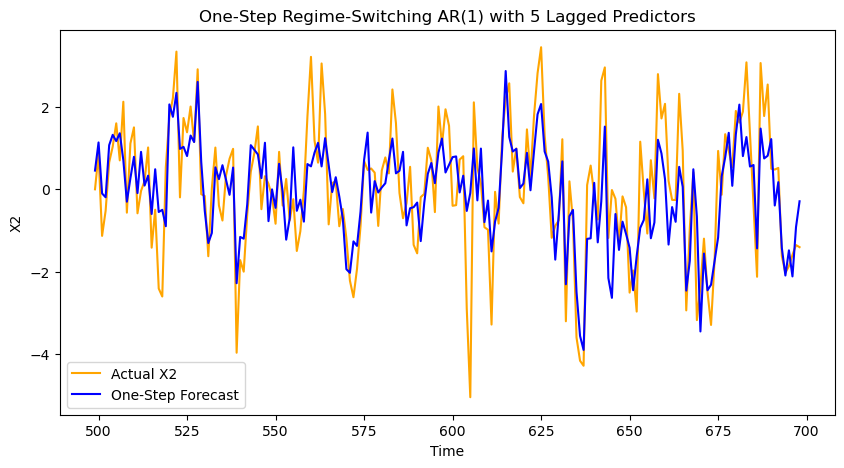

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from scipy.stats import norm

# 1) Load your full multivariate series, assumed to have columns X0, X1, X2, X3, X4:
df = pd.read_csv('data/simulated_time_series.csv')

# 2) Build lag-1 features for all 5 series:
for j in range(5):
    df[f'X{j}_lag1'] = df[f'X{j}'].shift(1)
df = df.dropna().reset_index(drop=True)

# 3) Split: rows 0–499 → train; 500–699 → test
train = df.iloc[:499]
test  = df.iloc[499:700]

# 4) Prepare endog & exog
y_train   = train['X2']                              # target is X2
exog_cols = [f'X{j}_lag1' for j in range(5)]         # lags of X0…X4
exog_train = train[exog_cols]

# 5) Fit a 2-regime switching regression with all lagged predictors
model = MarkovRegression(
    endog=y_train,
    k_regimes=2,
    exog=exog_train,
    trend='c',
    switching_trend=True,
    switching_exog=True,
    switching_variance=True
)
res = model.fit(em_iter=30, search_reps=10, disp=False)

# 6) Extract parameters
p00, p10 = res.params['p[0->0]'], res.params['p[1->0]']
P = np.array([[p00, 1-p00],
              [p10, 1-p10]])
intercepts = np.array([res.params['const[0]'], res.params['const[1]']])
# map exog names: x1→X0_lag1, x2→X1_lag1, …, x5→X4_lag1
betas = np.vstack([
    [res.params[f'x{k+1}[0]'], res.params[f'x{k+1}[1]']]
    for k in range(5)
]).T  # shape (2 regimes × 5 predictors)
sigmas = np.sqrt([res.params['sigma2[0]'], res.params['sigma2[1]']])

# 7) One-step forecasts on the test set
pi = res.filtered_marginal_probabilities.iloc[-1].values  # last filtered π
one_step = []
for _, row in test.iterrows():
    # propagate regime mix
    pi_pred = pi.dot(P)
    # regime-specific means: intercept + Σ β_j · Xj_lag1
    lag_vals = np.array([row[c] for c in exog_cols])
    mus = intercepts + (betas * lag_vals).sum(axis=1)
    # weighted forecast
    y_hat = pi_pred.dot(mus)
    one_step.append(y_hat)
    # update π with actual X2
    likelihoods = norm.pdf(row['X2'], loc=mus, scale=sigmas)
    pi = (pi_pred * likelihoods)
    pi /= pi.sum()

# 8) Plot
plt.figure(figsize=(10,5))
plt.plot(df.index[499:], df['X2'][499:], label='Actual X2', color='orange')
plt.plot(df.index[499:], one_step, label='One-Step Forecast', color='blue')
plt.legend(); plt.xlabel('Time'); plt.ylabel('X2')
plt.title('One-Step Regime-Switching AR(1) with 5 Lagged Predictors')
plt.show()


In [28]:
y_test = df['X2'][499:]
y_pred = one_step


# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)


# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")


R-squared (R2): 0.5805001599963362
MAE: 0.8230789532173323
RMSE: 1.0424461586705256
MAPE: 2.995696066559522


## VAR benchmark

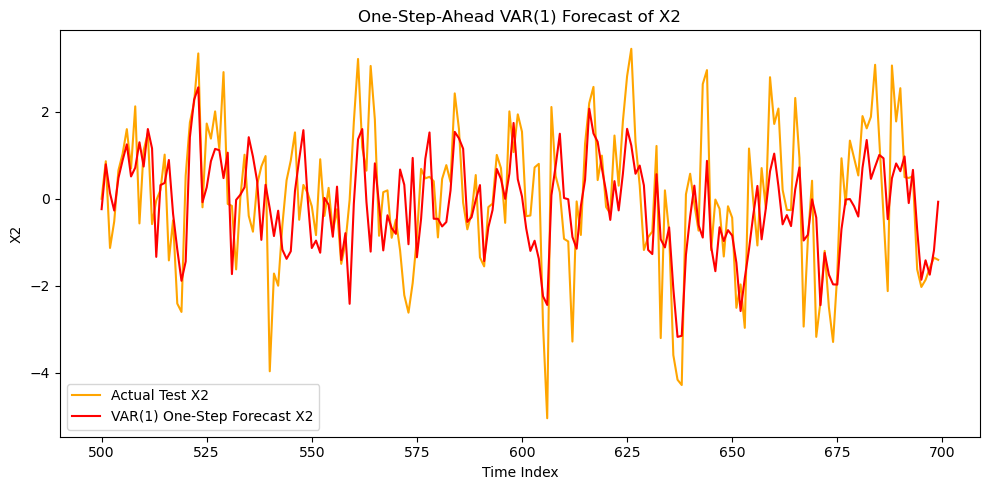

In [10]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Load data
df = pd.read_csv('data/simulated_time_series.csv')

# Split into training (0-499) and testing (500-699)
train = df.iloc[:500]
test = df.iloc[500:700]


# Fit VAR(1) on training data
model = VAR(train)
res = model.fit(maxlags=1)

# One-step-ahead forecasts on test range
lag_order = res.k_ar
history = train.values.copy()
one_step_preds = []

for obs in test.values:
    # Forecast one step using last lag_order observations
    last_obs = history[-lag_order:]
    yhat = res.forecast(y=last_obs, steps=1)
    # Extract X2 prediction
    one_step_preds.append(yhat[0, 2])
    # Append the actual observation to history for next forecast
    history = np.vstack([history, obs])

# Convert forecasts to Series aligned with test index
forecast_series = pd.Series(one_step_preds, index=test.index)

# Plot actual vs one-step forecast for X2
plt.figure(figsize=(10, 5))

plt.plot(test.index, test['X2'], label='Actual Test X2', color='orange')
plt.plot(forecast_series.index, forecast_series, label='VAR(1) One-Step Forecast X2', color='red')
plt.xlabel('Time Index')
plt.ylabel('X2')
plt.title('One-Step-Ahead VAR(1) Forecast of X2')
plt.legend()
plt.tight_layout()
plt.show()



In [11]:
y_test = test['X2']
y_pred = forecast_series


# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)


# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.3838081313873195
MAE: 0.9821912373582794
RMSE: 1.2634140873531585
MAPE: 2.7090060008987673
